# Hello World

In this Notebook, I will be taking my real first look at market data using `yfinance`, `pandas`, and `matplotlib`.

**Documentation References:**
1. `yfinance`: [GitHub](https://ranaroussi.github.io/yfinance/index.html)
2. `pandas`: [PyData](https://pandas.pydata.org/docs/)
3. `matplotlib`: [Matplotlib.org](https://matplotlib.org/stable/index.html)

To install yfinance, run the following code: `!pip install yfinance`

In [213]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

My essential libraries have been downloaded. Now we can:
1. Download stock data
2. View raw data
3. Plot closing prices

Let's begin with Step 1.

In [214]:
# We allow for a ticker input. If nothing was entered, the default is AAPL (Apple, Inc)
ticker = input("Enter the ticker: ")
if not ticker:
    ticker = "AAPL"

# Allow for the user to select the observation window
start_date = input("Enter the start date (YYYY-MM-DD): ")
if not start_date:
    start_date = "2024-01-01"

end_date = input("Enter the end date (YYYY-MM-DD): ")
if not end_date:
    end_date = "2025-01-01"

# Use the .Ticker() method to retrieve information about the company. In this case, the company's name
ticker_info = yf.Ticker(ticker).info
company_name = ticker_info['longName']

# We will download one year's worth of data and reference it with the data variable
data = yf.download(ticker, start=start_date,end=end_date)
trading_days = len(data)
if trading_days < 252:
    print(f"Warning: Only {trading_days} trading days. Annualized figures may be extrapolated")
print(f"Trading days: {trading_days}")

Enter the ticker:  MSFT
Enter the start date (YYYY-MM-DD):  2024-01-01
Enter the end date (YYYY-MM-DD):  2025-01-01


[*********************100%***********************]  1 of 1 completed

Trading days: 252


We can now view the raw data:

In [215]:
print(data.head(10)) # View the first ten rows
print(f"\nTrading days: {data.shape[0]}\nObserved columns: {data.shape[1]}") # The number of rows and columns

Price            Close        High         Low        Open    Volume
Ticker            MSFT        MSFT        MSFT        MSFT      MSFT
Date                                                                
2024-01-02  364.589447  369.534265  360.558873  367.528803  25258600
2024-01-03  364.324066  366.939024  362.269463  362.760996  23083500
2024-01-04  361.709045  366.781666  360.952096  364.392824  20901500
2024-01-05  361.522308  365.759318  360.293477  362.721649  21004600
2024-01-08  368.344757  368.846130  362.760953  363.046020  23134000
2024-01-09  369.426147  369.622743  364.904041  365.710162  20830000
2024-01-10  376.287933  377.664249  369.947180  369.996321  25514200
2024-01-11  378.116455  384.063989  373.938427  379.463250  27850800
2024-01-12  381.891449  382.097884  378.136132  378.961903  21661200
2024-01-16  383.660889  387.357224  381.055772  386.993494  27202300

Trading days: 252
Observed columns: 5


Let's chart the closing prices:

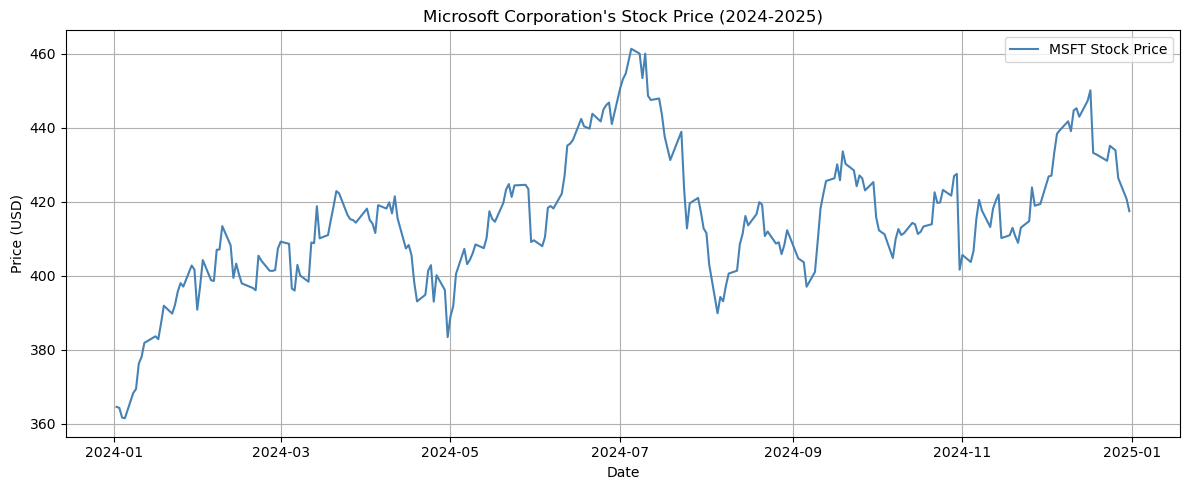

In [216]:
plt.figure(figsize=(12, 5))
plt.plot(data["Close"], label=f"{ticker} Stock Price", color="steelblue")
plt.title(f"{company_name}'s Stock Price ({start_date[0:4]}-{end_date[0:4]})")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Returns and Statistics

Now we have prices, which means we can calculate the returns between each closing price point. The formula is:
$ r_t = \frac{P_t-P_{t-1}}{P_{t-1}}$
- $ r_t $: The return at time $t$. In this case, $t$ is one day
- $ P_t $: The price at day $t$
- $ P_{t-1} $: The price at the previous day

For example, if yesterday's closing price was `$100` and today's closing price is `$110`, the return is: 
$ r_t = \frac{110-100}{100} = 0.1 $

When converted to a percentage: $ 0.1 \times 100\% = 10\% $
We see a 10 percent return if we had bought the stock yesterday and sold it today.

Pandas does this automatically with the `.pct_change()` method:

In [217]:
# Create a new column "Returns" that is equal to the percent change in the closing stock prices
data["Returns"] = data["Close"].pct_change().dropna()
print(data["Returns"].head(10))

Date
2024-01-02         NaN
2024-01-03   -0.000728
2024-01-04   -0.007178
2024-01-05   -0.000516
2024-01-08    0.018871
2024-01-09    0.002936
2024-01-10    0.018574
2024-01-11    0.004859
2024-01-12    0.009984
2024-01-16    0.004633
Name: Returns, dtype: float64


Now let's explore the data using the pandas `.describe()` method:

In [218]:
print(data["Returns"].describe())

mean_return = data["Returns"].mean()
print(f"The mean return is: {mean_return:.2%}")

count    251.000000
mean       0.000619
std        0.012567
min       -0.060527
25%       -0.006056
50%        0.001154
75%        0.009165
max        0.026600
Name: Returns, dtype: float64
The mean return is: 0.06%


# Annualization

Before proceeding, we can run a sanity check:
- There are 252 trading days in a year. A trading day count close to that number is reasonable.

It's nice to have a summary of data, but most investors typically hold stock for longer than one day. A mean return of 0.06%\* per day may not be a useful metric. 

## The Calculation

Return: $ (1+r)^{252}-1 $: Returns compound multiplicatively

Volatility: $ \sigma \times \sqrt{252} $: Variance scales linearly with time and standard deviation is the square root of variance

Sharpe: $ S_a \times \sqrt{252} $: Sharpe uses standard deviation

## In Practice

Let's annualize it:
$ (1+0.000619)^{252}-1=0.1688\approx16.88\%$ annual return on average.

We'll annualize volatility as well. Given a standard deviation of approximately 1.26\%\* per day:
$ 0.012567 \times \sqrt{252} = 0.19949494 \approx 19.95\%$ annual volatility.

Let's analyze the min and max daily returns:
- Min: Approximately $ -6.05\%$

  $ \frac{-6.05\%}{1.26\%} = -4.8\sigma $; The min is 4.8 standard deviations* below the mean. That's a crazy outlier event!

  (According to the 68-95.99.7 rule, 99.7\% of values fall between 3 standard deviations of the mean. This data point lies outside that range.)
- Max: Approximately $ 2.66\% $

  $ \frac{2.66\%}{1.26\%} = 2.11\sigma $; The max is 2.11 standard deviations* above the mean.

\* *Figure was obtained using MSFT returns from 2024-01-01 to 2025-01-01*

In [219]:
# Calculate Mean, Std Dev
mean_return = data["Returns"].mean()
std_return = data["Returns"].std()
print(f"The mean of daily returns is: {mean_return:.2%}.\nThe volatility of daily returns is: {std_return:.2%}.")

The mean of daily returns is: 0.06%.
The volatility of daily returns is: 1.26%.


In [220]:
# Annualize
ann_mean_return = (1+mean_return) ** 252 - 1
ann_std_return = std_return * (252 ** 0.5)
print(f"The annualized mean return is: {ann_mean_return:.2%}.\nThe annualized volatility is: {ann_std_return:.2%}.")

The annualized mean return is: 16.87%.
The annualized volatility is: 19.95%.


# The Sharpe Ratio
*"A measure of an investment's risk-adjusted performance, calculated by comparing its return to that of a risk-free asset" - Investopedia*

In other words, the Sharpe Ratio measures excess return per unit of risk. The formula is: 
$Sharpe~Ratio = \frac{R_p-R_f}{\sigma_p}$
- $R_p$ Is the return on portfolio, but in this case our "portfolio" only contains one stock
- $R_f$ Is the risk-free rate. We will use the 10-Year U.S. Treasury Yield Index (^TNX) to approximate this
- $\sigma_p$ Is the portfolio's volatility

The only way that the Sharpe Ratio can be negative is if the numerator is negative. In that case, our portfolio's return is less than the risk-free rate. A Sharpe Ratio of zero means that our portfolio's return matches the risk-free rate. Meanwhile, Sharpe Ratios greater than 0 indicate returns higher than the risk-free rate.

In [221]:
# Obtain 10-year Treasury yield data (^TNX)
# If we want to use the 13-week (3 month) Treasury yield data (^IRX)
tbill = yf.download("^TNX",start=start_date,end=end_date)
print(tbill.head(10))

[*********************100%***********************]  1 of 1 completed

Price       Close   High    Low   Open Volume
Ticker       ^TNX   ^TNX   ^TNX   ^TNX   ^TNX
Date                                         
2024-01-02  3.946  3.973  3.918  3.969      0
2024-01-03  3.907  4.008  3.894  3.978      0
2024-01-04  3.991  4.006  3.971  3.974      0
2024-01-05  4.042  4.099  3.953  4.038      0
2024-01-08  4.002  4.063  3.966  4.059      0
2024-01-09  4.019  4.053  3.996  4.047      0
2024-01-10  4.030  4.038  3.985  3.992      0
2024-01-11  3.977  4.068  3.973  3.994      0
2024-01-12  3.950  4.007  3.916  4.003      0
2024-01-16  4.066  4.083  3.990  4.003      0


In [222]:
# Quoted at an annual rate, so we need to convert it into daily units in order to calculate an accurate Sharpe Ratio
# .item() extracts the number from the pandas object. Note that IRX and TNX are stored in a multi-level column structure
rf_annual = tbill["Close"].mean().item() / 100
rf_daily = (1 + rf_annual) ** (1 / 252) - 1
print(f"The Risk-Free Rate from {start_date} to {end_date} is approximately: {rf_annual:.2%}")

# Calculate Daily Sharpe Ratio
sharpe = (mean_return - rf_daily) / std_return
# Annualize sharpe ratio
ann_sharpe = sharpe * (252 ** 0.5)

print(f"The Sharpe Ratio of {ticker} is {ann_sharpe:.2f}")

The Risk-Free Rate from 2024-01-01 to 2025-01-01 is approximately: 4.21%
The Sharpe Ratio of MSFT is 0.58


# Summary Statistics

In [223]:
print(f"Mean daily return: {mean_return:.4%}")
print(f"Std daily return: {std_return:.4%}")
print(f"Risk-free rate annual: {rf_annual:.4%}")
print(f"Risk-free rate daily: {rf_daily:.4%}")
print(f"Trading days: {trading_days}")
print(f"Daily Sharpe: {sharpe:.2f}")
print(f"Annualized Sharpe: {ann_sharpe:.2f}")

Mean daily return: 0.0619%
Std daily return: 1.2567%
Risk-free rate annual: 4.2071%
Risk-free rate daily: 0.0164%
Trading days: 252
Daily Sharpe: 0.04
Annualized Sharpe: 0.58


# Comparison to the Market

Let's do a comparison of the chosen stock to the market. To approximate the market, we will use `SPY`, or the S&P 500 ETF. 

We will also use a defensive stock, The Coca-Cola Company (KO), to demonstrate a low Sharpe ratio.

[*********************100%***********************]  1 of 1 completed


Type a defensive stock here (Ex. 'KO'):  KO


[*********************100%***********************]  1 of 1 completed


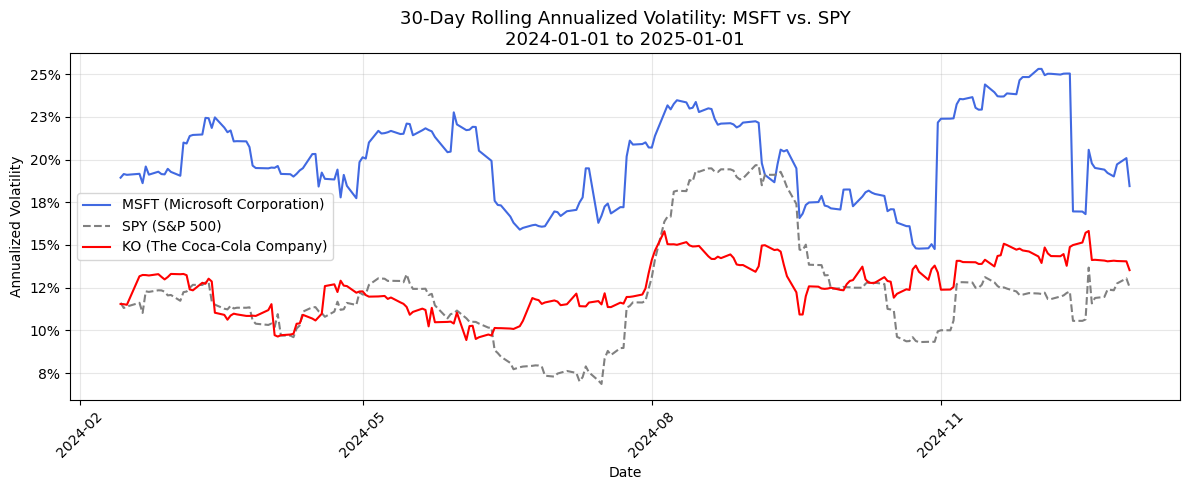

In [224]:
import matplotlib.dates as mdates

# Download market data for the same period
market = yf.download("SPY", start=start_date, end=end_date)
market["Returns"] = market["Close"].pct_change()

# Download a defensive stock data for the same period
defstock_ticker = input("Type a defensive stock here (Ex. 'KO'): ")
defstock = yf.download(defstock_ticker, start=start_date, end=end_date)
defstock["Returns"] = defstock["Close"].pct_change()
defstock_name = yf.Ticker(defstock_ticker).info['longName']


# Calculate rolling 30-day volatility (annualized) for both
window = 30
data["RollingVol"] = data["Returns"].rolling(window).std() * (252 ** 0.5)
market["RollingVol"] = market["Returns"].rolling(window).std() * (252 ** 0.5)
defstock["RollingVol"] = defstock["Returns"].rolling(window).std() * (252 ** 0.5)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(data.index, data["RollingVol"], label=f"{ticker} ({company_name})", color="royalblue", linewidth=1.5)
ax.plot(market.index, market["RollingVol"], label="SPY (S&P 500)", color="grey", linewidth=1.5, linestyle="--")
ax.plot(defstock.index, defstock["RollingVol"], label=f"{defstock_ticker} ({defstock_name})", color="red", linewidth=1.5)

# Formatting
ax.set_title(f"30-Day Rolling Annualized Volatility: {ticker} vs. SPY\n{start_date} to {end_date}", fontsize=13)
ax.set_xlabel("Date")
ax.set_ylabel("Annualized Volatility")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()